# Trabajo Final de Machine Learning

## Preparación y análisis exploratorio de datos financieros

Este notebook presenta el avance inicial de una solución para analizar datos históricos del índice S&P 500. En esta etapa se aplican **Pandas** y **NumPy** para cargar, explorar, limpiar, transformar y preparar la información antes de implementar los modelos predictivos.

## Problemática

Una empresa de análisis financiero maneja grandes volúmenes de datos en archivos CSV, pero no cuenta con un procedimiento eficiente y reproducible para limpiarlos, analizarlos y prepararlos antes de aplicar Machine Learning. Esta situación dificulta la identificación de tendencias y la toma de decisiones basada en datos.

## Objetivo del avance

Preparar un dataset histórico del índice S&P 500 mediante Pandas y NumPy, realizando su ingesta, exploración, limpieza, transformación y análisis descriptivo. El resultado servirá como base para definir las variables independientes (X), la variable objetivo (y) y el modelo de clasificación en el siguiente avance.

### Alcance actual

- Lectura del archivo CSV.
- Exploración de filas, columnas y tipos de datos.
- Detección de valores nulos, duplicados y datos inválidos.
- Conversión y traducción de columnas.
- Creación de indicadores financieros básicos.
- Análisis estadístico con Pandas y NumPy.
- Visualización de distribuciones, evolución y correlaciones.

## 1. Importación de librerías

Se importan las librerías necesarias para manipular, analizar y visualizar los datos.

In [61]:
# Importa NumPy para realizar operaciones numéricas con vectores y matrices
import numpy as np

# Importa Pandas para trabajar con DataFrames y archivos CSV
import pandas as pd

# Importa Matplotlib y Seaborn para crear visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Configura el tamaño y estilo predeterminados de los gráficos
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga del dataset

El archivo se encuentra en la carpeta `data`, mientras que este notebook se ejecuta desde la carpeta `notebooks`. La clase `Path` permite construir y verificar la ruta antes de leer el CSV.

In [62]:
from pathlib import Path

# Define la ubicación del archivo original
ruta_archivo = Path("../data/snp500_history.csv")

# Detiene la ejecución con un mensaje claro si el archivo no existe
if not ruta_archivo.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo en: {ruta_archivo.resolve()}"
    )

# Lee el CSV y lo convierte en un DataFrame
df = pd.read_csv(ruta_archivo)

print("Archivo cargado:", ruta_archivo.resolve())
print("Dimensiones originales:", df.shape)

Archivo cargado: C:\Users\KarLoz\Documents\1-PROYECTOS\trabajo_final_machine_learning\data\snp500_history.csv
Dimensiones originales: (23970, 8)


## 3. Exploración inicial

La exploración permite conocer la estructura del dataset antes de modificarlo. Cada fila representa una fecha de negociación y cada columna contiene una característica financiera.

In [63]:
# Muestra una primera muestra del contenido
display(df.head(10))

# Informa la cantidad de filas, columnas y sus nombres
cantidad_filas, cantidad_columnas = df.shape
print("Cantidad de filas:", cantidad_filas)
print("Cantidad de columnas:", cantidad_columnas)
print("Columnas originales:", df.columns.tolist())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1,1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
2,1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
3,1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
4,1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
5,1928-01-09 00:00:00-05:00,17.500000,17.500000,17.500000,17.500000,0,0.0,0.0
6,1928-01-10 00:00:00-05:00,17.370001,17.370001,17.370001,17.370001,0,0.0,0.0
7,1928-01-11 00:00:00-05:00,17.350000,17.350000,17.350000,17.350000,0,0.0,0.0
8,1928-01-12 00:00:00-05:00,17.469999,17.469999,17.469999,17.469999,0,0.0,0.0
9,1928-01-13 00:00:00-05:00,17.580000,17.580000,17.580000,17.580000,0,0.0,0.0


Cantidad de filas: 23970
Cantidad de columnas: 8
Columnas originales: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [64]:
# Muestra los tipos de datos y la cantidad de valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          23970 non-null  str    
 1   Open          23970 non-null  float64
 2   High          23970 non-null  float64
 3   Low           23970 non-null  float64
 4   Close         23970 non-null  float64
 5   Volume        23970 non-null  int64  
 6   Dividends     23970 non-null  float64
 7   Stock Splits  23970 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 1.5 MB


## 4. Limpieza de datos

Se revisan valores nulos, registros duplicados, columnas sin nombre, fechas repetidas, precios inválidos y columnas que no presentan variación. Como se trata de una serie temporal, si existe un periodo antiguo con precios incompletos se conserva un tramo posterior continuo, evitando huecos extensos entre observaciones.

In [65]:
# Cuenta los valores nulos de cada columna
valores_nulos = df.isnull().sum()

if (valores_nulos > 0).any():
    print("Columnas con valores nulos:")
    display(valores_nulos[valores_nulos > 0])
else:
    print("El dataset no contiene valores nulos.")

El dataset no contiene valores nulos.


In [66]:
# Elimina filas completamente repetidas y registra el resultado
filas_antes = len(df)
df = df.drop_duplicates().copy()
filas_eliminadas = filas_antes - len(df)

print("Filas duplicadas eliminadas:", filas_eliminadas)

Filas duplicadas eliminadas: 0


In [67]:
# Elimina columnas auxiliares creadas al exportar otros DataFrames
columnas_sin_nombre = df.columns.str.contains(
    "^Unnamed",
    case=False,
    regex=True
)

df = df.loc[:, ~columnas_sin_nombre].copy()
print("Columnas después de eliminar nombres auxiliares:", df.columns.tolist())

Columnas después de eliminar nombres auxiliares: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [68]:
# Convierte Date de texto a fecha y normaliza la zona horaria
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    utc=True
).dt.tz_localize(None).dt.normalize()

# Elimina fechas que no pudieron convertirse
fechas_invalidas = df["Date"].isna().sum()
df = df.dropna(subset=["Date"]).copy()

# Ordena cronológicamente y elimina fechas repetidas
fechas_duplicadas = df.duplicated(subset=["Date"]).sum()
df = (
    df.sort_values("Date")
      .drop_duplicates(subset=["Date"], keep="last")
      .reset_index(drop=True)
)

print("Fechas inválidas eliminadas:", fechas_invalidas)
print("Fechas duplicadas eliminadas:", fechas_duplicadas)
print("Tipo de Date:", df["Date"].dtype)

Fechas inválidas eliminadas: 0
Fechas duplicadas eliminadas: 0
Tipo de Date: datetime64[us]


In [69]:
# Traduce los nombres para facilitar la lectura y exposición
df = df.rename(columns={
    "Date": "Fecha",
    "Open": "Apertura",
    "High": "Maximo",
    "Low": "Minimo",
    "Close": "Cierre",
    "Volume": "Volumen",
    "Dividends": "Dividendos",
    "Stock Splits": "Division_Acciones"
})

print("Columnas traducidas:", df.columns.tolist())

Columnas traducidas: ['Fecha', 'Apertura', 'Maximo', 'Minimo', 'Cierre', 'Volumen', 'Dividendos', 'Division_Acciones']


In [70]:
# Comprueba que los precios financieros sean mayores que cero
columnas_precios = ["Apertura", "Maximo", "Minimo", "Cierre"]
conteo_precios_invalidos = (df[columnas_precios] <= 0).sum()

print("Valores menores o iguales a cero por columna:")
display(conteo_precios_invalidos)

# Identifica las filas que tienen al menos un precio inválido
mascara_precios_invalidos = (df[columnas_precios] <= 0).any(axis=1)
filas_con_precio_invalido = mascara_precios_invalidos.sum()

# Conserva un periodo cronológico continuo posterior al último precio inválido
if filas_con_precio_invalido > 0:
    ultima_fecha_incompleta = df.loc[
        mascara_precios_invalidos,
        "Fecha"
    ].max()

    df = (
        df.loc[df["Fecha"] > ultima_fecha_incompleta]
          .reset_index(drop=True)
          .copy()
    )

    print("Última fecha con precios incompletos:", ultima_fecha_incompleta)
else:
    df = df.reset_index(drop=True).copy()

print("Filas con precios inválidos detectadas:", filas_con_precio_invalido)
print("Periodo continuo seleccionado:", df["Fecha"].min(), "a", df["Fecha"].max())

Valores menores o iguales a cero por columna:


Apertura    5075
Maximo         0
Minimo         0
Cierre         0
dtype: int64

Última fecha con precios incompletos: 1982-04-19 00:00:00
Filas con precios inválidos detectadas: 5075
Periodo continuo seleccionado: 1982-04-20 00:00:00 a 2023-06-02 00:00:00


In [71]:
# Identifica columnas que contienen un único valor y no aportan variación
columnas_constantes = [
    columna
    for columna in df.columns
    if df[columna].nunique(dropna=False) <= 1
]

print("Columnas constantes eliminadas:", columnas_constantes)
df = df.drop(columns=columnas_constantes)

print("Dimensiones después de la limpieza:", df.shape)
display(df.head())

Columnas constantes eliminadas: ['Dividendos', 'Division_Acciones']
Dimensiones después de la limpieza: (10368, 6)


,Fecha,Apertura,Maximo,Minimo,Cierre,Volumen
0,1982-04-20,115.800003,117.139999,114.830002,115.440002,54610000
1,1982-04-21,115.480003,115.870003,115.300003,115.720001,57820000
2,1982-04-22,115.720001,117.250000,115.720001,117.190002,64470000
3,1982-04-23,118.019997,118.639999,117.190002,118.639999,71840000
4,1982-04-26,118.940002,119.330002,118.250000,119.260002,60500000


## 5. Transformación de datos

Se crean nuevas columnas mediante operaciones vectorizadas. El retorno diario representa la variación porcentual del cierre, mientras que el rango diario muestra la diferencia relativa entre el precio máximo y mínimo.

In [72]:
# Calcula la variación porcentual respecto al cierre anterior
df["Retorno_Diario"] = df["Cierre"].pct_change(fill_method=None)

# Calcula la amplitud diaria del precio respecto a la apertura
df["Rango_Diario"] = (
    (df["Maximo"] - df["Minimo"]) / df["Apertura"]
)

# Extrae el año para realizar una agrupación cronológica
df["Anio"] = df["Fecha"].dt.year

display(
    df[[
        "Fecha",
        "Apertura",
        "Maximo",
        "Minimo",
        "Cierre",
        "Volumen",
        "Retorno_Diario",
        "Rango_Diario"
    ]].head(10)
)

,Fecha,Apertura,Maximo,Minimo,Cierre,Volumen,Retorno_Diario,Rango_Diario
0,1982-04-20,115.800003,117.139999,114.830002,115.440002,54610000,NaN,0.019948
1,1982-04-21,115.480003,115.870003,115.300003,115.720001,57820000,0.002425,0.004936
2,1982-04-22,115.720001,117.250000,115.720001,117.190002,64470000,0.012703,0.013222
3,1982-04-23,118.019997,118.639999,117.190002,118.639999,71840000,0.012373,0.012286
4,1982-04-26,118.940002,119.330002,118.250000,119.260002,60500000,0.005226,0.009080
5,1982-04-27,119.070000,119.260002,117.730003,118.000000,56480000,-0.010565,0.012850
6,1982-04-28,117.830002,118.050003,116.940002,117.260002,50530000,-0.006271,0.009420
7,1982-04-29,116.400002,117.239998,116.110001,116.139999,51330000,-0.009551,0.009708
8,1982-04-30,116.209999,116.779999,116.070000,116.440002,48200000,0.002583,0.006110
9,1982-05-03,115.959999,116.820000,115.910004,116.820000,46490000,0.003263,0.007847


## 6. Análisis estadístico con Pandas

Las estadísticas descriptivas resumen la distribución, tendencia central y dispersión de las variables numéricas.

In [73]:
# Genera las estadísticas y transpone la tabla para facilitar su lectura
estadisticas = df.describe().T
display(estadisticas)

,count,mean,min,25%,50%,75%,max,std
Fecha,10368,2002-11-01 06:32:30,1982-04-20 00:00:00,1992-07-19 06:00:00,2002-10-28 12:00:00,2013-02-14 06:00:00,2023-06-02 00:00:00,NaN
Apertura,10368.0,1287.577445,102.419998,415.597496,1122.069946,1544.777466,4804.509766,1061.788124
Maximo,10368.0,1295.274208,103.010002,417.24749,1128.190002,1551.115021,4818.620117,1067.822552
Minimo,10368.0,1279.342101,102.199997,413.532509,1114.945007,1536.730042,4780.040039,1055.237474
Cierre,10368.0,1287.846211,102.419998,415.657509,1121.880005,1545.892548,4796.560059,1061.908154
Volumen,10368.0,2001529600.694444,14990000.0,222510000.0,1336150000.0,3585047500.0,11456230000.0,1897780298.809554
Retorno_Diario,10367.0,0.000414,-0.204669,-0.004512,0.000571,0.005713,0.1158,0.011438
Rango_Diario,10368.0,0.012377,0.0,0.006747,0.010048,0.015122,0.204705,0.009173
Anio,10368.0,2002.333912,1982.0,1992.0,2002.0,2013.0,2023.0,11.882142


In [74]:
# Resume el comportamiento financiero por año
resumen_anual = (
    df.groupby("Anio")
      .agg(
          Cierre_Promedio=("Cierre", "mean"),
          Volumen_Promedio=("Volumen", "mean"),
          Retorno_Promedio=("Retorno_Diario", "mean")
      )
)

print("Resumen de los últimos diez años disponibles:")
display(resumen_anual.tail(10))

Resumen de los últimos diez años disponibles:


,Cierre_Promedio,Volumen_Promedio,Retorno_Promedio
Anio,,,
2014,1931.376110,3.354783e+09,0.000454
2015,2061.067741,3.655629e+09,0.000019
2016,2094.651264,3.904086e+09,0.000395
2017,2449.076379,3.420175e+09,0.000716
2018,2746.214183,3.634743e+09,-0.000199
2019,2913.356380,3.558550e+09,0.001038
2020,3217.855849,4.922448e+09,0.000832
2021,4273.385635,4.417140e+09,0.000980
2022,4098.514748,4.617723e+09,-0.000745


## 7. Operaciones con NumPy

Pandas organiza los datos en un DataFrame. Después de la limpieza, NumPy permite extraer vectores y matrices numéricas de alto rendimiento que posteriormente podrán alimentar un algoritmo de Machine Learning.

In [75]:
# Convierte los retornos válidos en un vector de NumPy
vector_retornos = df["Retorno_Diario"].dropna().to_numpy()

print("Dimensiones del vector:", vector_retornos.shape)
print("Retorno promedio:", np.mean(vector_retornos))
print("Desviación estándar:", np.std(vector_retornos))
print("Retorno mínimo:", np.min(vector_retornos))
print("Retorno máximo:", np.max(vector_retornos))

Dimensiones del vector: (10367,)
Retorno promedio: 0.0004144603296136934
Desviación estándar: 0.0114373762928127
Retorno mínimo: -0.2046693079969436
Retorno máximo: 0.11580036951513706


In [76]:
# Extrae una matriz con las características financieras básicas
columnas_matriz = [
    "Apertura",
    "Maximo",
    "Minimo",
    "Cierre",
    "Volumen",
    "Retorno_Diario",
    "Rango_Diario"
]

matriz_financiera = (
    df[columnas_matriz]
    .dropna()
    .to_numpy()
)

print("Dimensiones de la matriz financiera:", matriz_financiera.shape)
print("Primeras cinco filas de la matriz:")
print(matriz_financiera[:5])

Dimensiones de la matriz financiera: (10367, 7)
Primeras cinco filas de la matriz:
[[ 1.15480003e+02  1.15870003e+02  1.15300003e+02  1.15720001e+02
   5.78200000e+07  2.42549180e-03  4.93591685e-03]
 [ 1.15720001e+02  1.17250000e+02  1.15720001e+02  1.17190002e+02
   6.44700000e+07  1.27030868e-02  1.32215586e-02]
 [ 1.18019997e+02  1.18639999e+02  1.17190002e+02  1.18639999e+02
   7.18400000e+07  1.23730431e-02  1.22860277e-02]
 [ 1.18940002e+02  1.19330002e+02  1.18250000e+02  1.19260002e+02
   6.05000000e+07  5.22591664e-03  9.08022372e-03]
 [ 1.19070000e+02  1.19260002e+02  1.17730003e+02  1.18000000e+02
   5.64800000e+07 -1.05651695e-02  1.28495741e-02]]


## 8. Visualización de datos

Las visualizaciones permiten reconocer la distribución de los retornos, la evolución histórica del índice y las relaciones entre las variables.

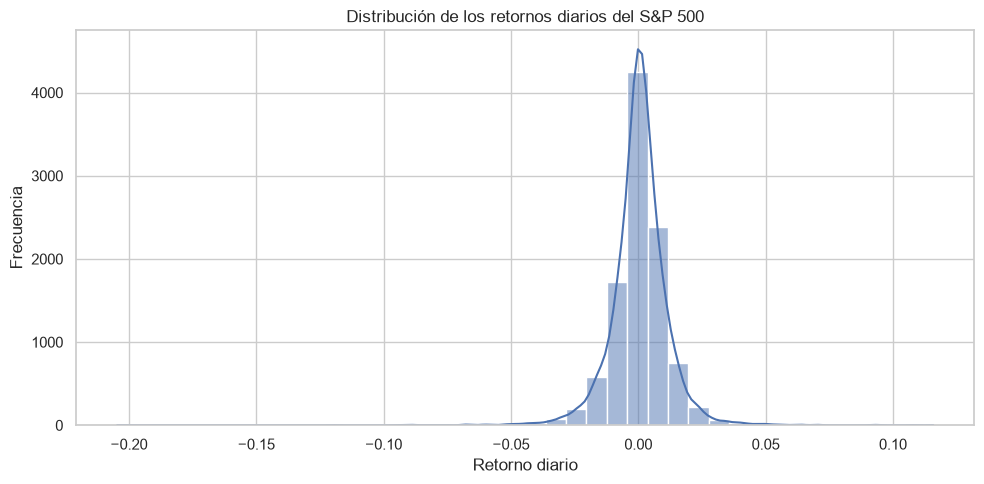

In [77]:
# Muestra la distribución de la variación porcentual diaria
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df.dropna(subset=["Retorno_Diario"]),
    x="Retorno_Diario",
    bins=40,
    kde=True
)

plt.title("Distribución de los retornos diarios del S&P 500")
plt.xlabel("Retorno diario")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

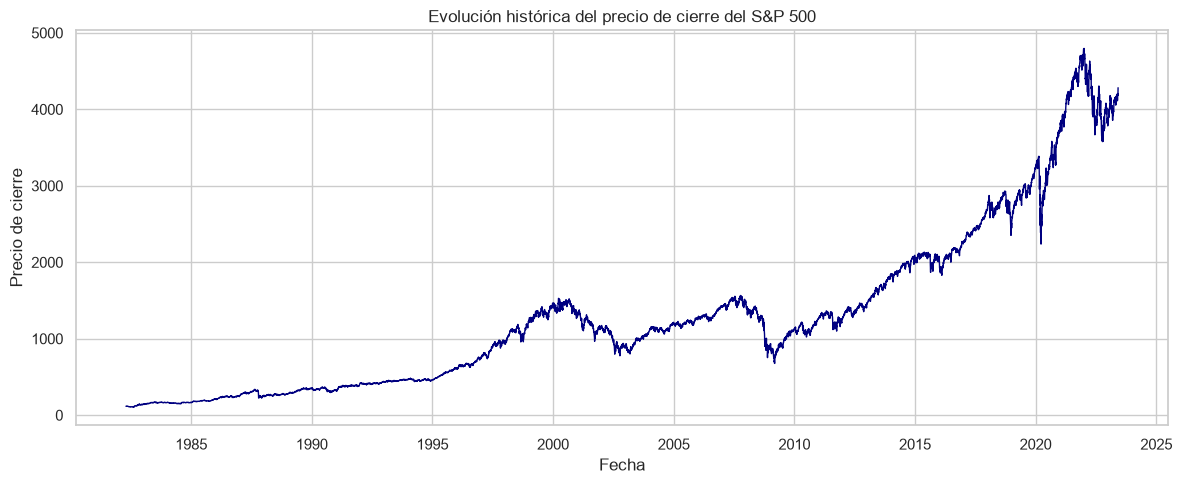

In [78]:
# Representa la evolución del precio de cierre
plt.figure(figsize=(12, 5))
plt.plot(df["Fecha"], df["Cierre"], color="navy", linewidth=1)

plt.title("Evolución histórica del precio de cierre del S&P 500")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.tight_layout()
plt.show()

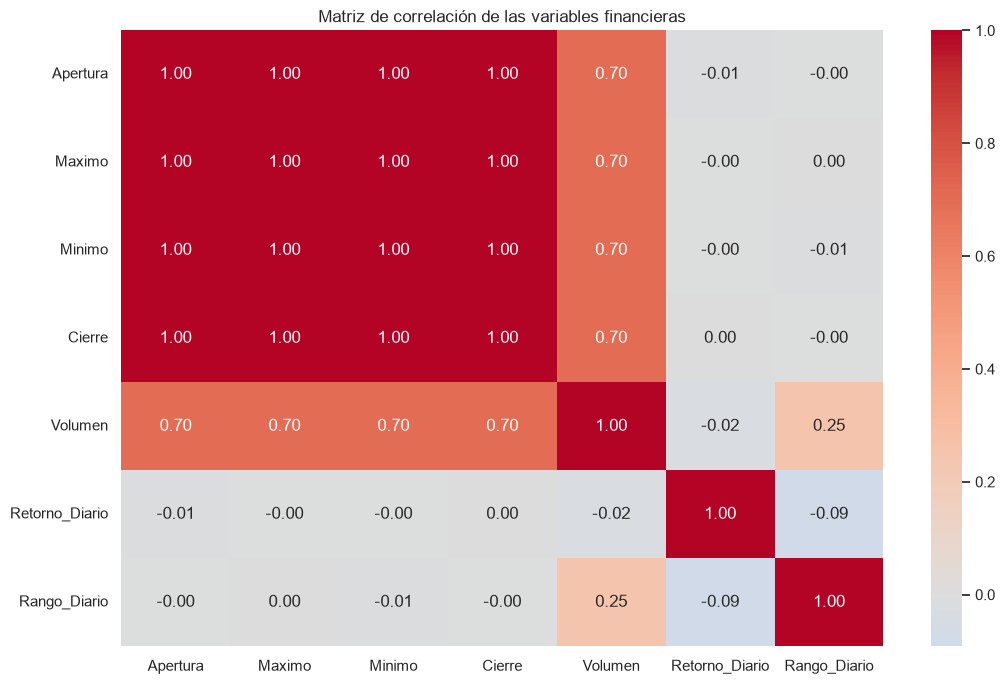

In [79]:
# Calcula y representa la correlación de las variables numéricas relevantes
columnas_correlacion = [
    "Apertura",
    "Maximo",
    "Minimo",
    "Cierre",
    "Volumen",
    "Retorno_Diario",
    "Rango_Diario"
]

matriz_correlacion = df[columnas_correlacion].corr()

plt.figure(figsize=(11, 7))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Matriz de correlación de las variables financieras")
plt.tight_layout()
plt.show()

## 9. Conclusiones preliminares

- El archivo original contiene **23,970 registros y 8 columnas**, sin valores nulos ni filas duplicadas.
- La columna de fecha fue convertida a un tipo temporal y las variables fueron traducidas al español.
- Se detectaron **5,075 aperturas con valor cero**, concentradas hasta el 19 de abril de 1982. Para evitar un hueco de veinte años se seleccionó un periodo continuo desde el 20 de abril de 1982 hasta el 2 de junio de 2023.
- Después de la limpieza quedaron **10,368 registros y 6 columnas originales útiles**. Dividendos y división de acciones fueron eliminadas por contener únicamente ceros.
- El retorno diario promedio fue aproximadamente **0.041 %**, con una desviación estándar de **1.144 %**.
- Se crearon el retorno y el rango diario mediante operaciones vectorizadas, y se extrajo una matriz de NumPy con **10,367 filas y 7 características numéricas**.
- Las visualizaciones muestran la concentración de los retornos alrededor de cero, el crecimiento histórico del índice y la fuerte correlación entre apertura, máximo, mínimo y cierre.

En el siguiente avance se definirán las variables independientes (X) y la variable dependiente (y), se dividirán cronológicamente los datos y se entrenará un primer modelo de clasificación con Scikit-learn.